# Assignment — Logistic Regression on `penguins.csv`

**Question:** given a penguin's measurements, is it male or female?

Target: `sex` &nbsp;·&nbsp; File: `penguins.csv`

Use only the numeric columns: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`,
`body_mass_g`.

**Keep this notebook.** Next class we will come back to the model you build here and
measure it properly.

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
penguin=pd.read_csv("penguins.csv")
penguin.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## 1. Look at the data

> **Flow:** Shape, columns, missing values.

Run `.info()`. Which columns have missing values, and how many?

In [28]:
print("Shape",penguin.shape)
penguin.info()

Shape (344, 7)
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [29]:
print("Columns with number of missing values",(penguin.isna()).sum())

Columns with number of missing values species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [30]:
print("Total number of missing values",penguin.isna().sum().sum())

Total number of missing values 19


How many male and how many female? Use `sns.countplot`.

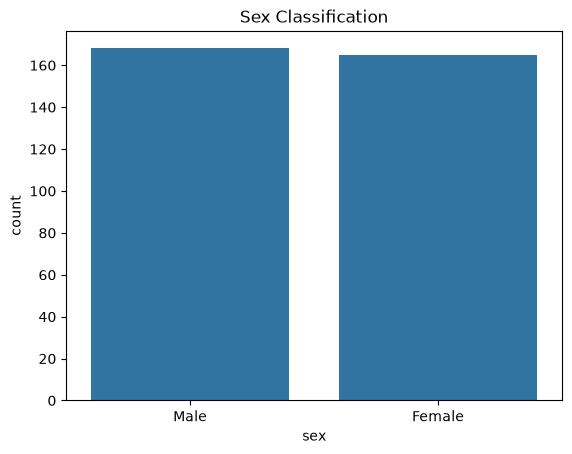

In [31]:
sns.countplot(data=penguin, x="sex")
plt.title("Sex Classification")
plt.show()

*Counts:* &nbsp;&nbsp; *Are the two classes roughly equal, or is one much bigger?*

Ans: The two classes are roughly equal

Now compare the two groups on one measurement. Use `sns.barplot` with `x='sex'` and
`y='body_mass_g'`.

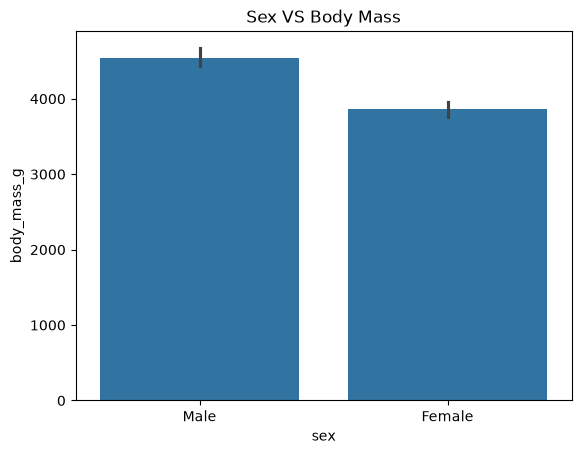

In [32]:
sns.barplot(data=penguin, x="sex", y="body_mass_g")
plt.title("Sex VS Body Mass")
plt.show()

**Q.** Looking at that plot, does `body_mass_g` look useful for telling males and females
apart? One line.

Yes, because there is a major difference in the average values for males and females.

---
## 2. Clean

> **Flow:** The target cannot be guessed. Rows missing it have to go.

`sex` is what we are trying to predict, so we cannot fill it in. Keep the four numeric
columns plus `sex`, then `dropna()`.

In [33]:
penguin.dropna(subset=['sex'], inplace=True)

In [34]:
penguin.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    str    
 1   island             333 non-null    str    
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 20.8 KB


In [35]:
penguin.drop(columns=['species','island'],inplace=True)

In [36]:
penguin.info()

<class 'pandas.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     333 non-null    float64
 1   bill_depth_mm      333 non-null    float64
 2   flipper_length_mm  333 non-null    float64
 3   body_mass_g        333 non-null    float64
 4   sex                333 non-null    str    
dtypes: float64(4), str(1)
memory usage: 15.6 KB


In [37]:
print("No of missing values:",penguin.isna().sum().sum())

No of missing values: 0


*How many rows are left?*

In [38]:
print("Rows left",penguin.shape[0])

Rows left 333


The target is text — `Male` and `Female`. Map it to numbers:
`{'Female': 0, 'Male': 1}`.

In [39]:
penguin['sex']=penguin['sex'].map({'Male':1, 'Female':0})

In [40]:
penguin.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,1


---
## 3. Features and target

In [41]:
x=penguin.drop(columns=['sex'])
y=penguin['sex']

---
## 4. Split

> **Flow:** `test_size=0.2`, `random_state=42`, `stratify=y`.

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, stratify=y, random_state=42)

**Q.** Why do we use `stratify=y` here? One line.

We should equally divide the output so that machine training is a success and can be done with efficiency

---
## 5. Train the model

> **Flow:** Two lines, same as always.

Train `LogisticRegression(max_iter=1000)` and predict on the test set.

In [44]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

**Q.** What does `max_iter=1000` do? One line.

Only a max of 1000 is allowed which increase the optimization of the model

---
## 6. Accuracy

In [45]:
y_predict=model.predict(x_test)

In [46]:
from sklearn.metrics import accuracy_score
acc_score=accuracy_score(y_predict,y_test)
print("Accuracy score:",acc_score)

Accuracy score: 0.8656716417910447
